# K-Nearest Neighbors — An Illustrated Tour

> KNN makes no assumptions about the data distribution. To classify a new point, it simply finds the $k$ closest training points and takes a **majority vote**.

---

**What we cover:**
- The core idea — classify by neighborhood
- Effect of $k$ — from memorization to smooth boundaries
- Distance metrics — Euclidean, Manhattan
- Why feature scaling is critical
- The curse of dimensionality
- Metrics — confusion matrix, ROC

## The picture — class = majority vote among the K nearest training points

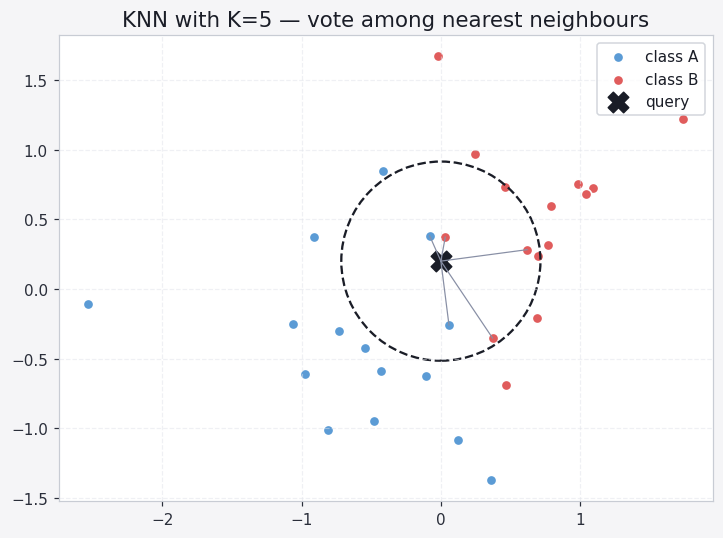

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
rng = np.random.RandomState(0)
A = rng.randn(15, 2)*0.6 + np.array([-1, -0.5])
B = rng.randn(15, 2)*0.6 + np.array([ 1,  0.5])
q = np.array([0, 0.2])
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(A[:,0], A[:,1], s=45, color=P[0], edgecolor='white', label='class A')
ax.scatter(B[:,0], B[:,1], s=45, color=P[1], edgecolor='white', label='class B')
ax.scatter(*q, s=180, marker='X', color='#1a1d27', label='query')
all_pts = np.vstack([A, B])
d = np.linalg.norm(all_pts - q, axis=1)
K = 5; nn = np.argsort(d)[:K]
ax.add_patch(Circle(q, d[nn[-1]]+0.05, fill=False, lw=1.5, ls='--', edgecolor='#1a1d27'))
for i in nn: ax.plot([q[0], all_pts[i,0]], [q[1], all_pts[i,1]], color='#888fa5', lw=0.8)
ax.set_aspect('equal'); ax.set_title(f'KNN with K={K} — vote among nearest neighbours')
ax.legend(); ax.grid(True); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_classification, make_moons
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (confusion_matrix, roc_curve, auc,
                              accuracy_score, precision_score, recall_score, f1_score)

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7', 'axes.facecolor':'#ffffff',
    'axes.edgecolor':'#c8ccd4',   'axes.labelcolor':'#1a1d27',
    'axes.titlecolor':'#1a1d27',  'xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a',      'grid.color':'#e0e3ea',
    'grid.linestyle': '--',        'grid.alpha': 0.5,
    'text.color':'#1a1d27',       'font.family': 'DejaVu Sans',
    'axes.titlesize': 17,          'axes.labelsize': 13,
    'xtick.labelsize': 11,         'ytick.labelsize': 11,
    'legend.fontsize': 11,         'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4', 'figure.dpi': 120,
}
plt.rcParams.update(PLT_STYLE)

C0='#5b9bd5'; C1='#e05c5c'; CB='#f4b942'; CM='#7ecba1'; CH='#56b6c2'; CP='#c678dd'

np.random.seed(3)
X2, y2 = make_moons(n_samples=200, noise=0.25, random_state=3)
sc2 = StandardScaler(); X2s = sc2.fit_transform(X2)
xx, yy = np.meshgrid(np.linspace(-2.5,3.5,300), np.linspace(-2.0,2.5,300))

X, y = make_classification(n_samples=200, n_features=20, n_informative=10, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr); X_te_s = sc.transform(X_te)
print('Ready')

Ready


---
## The Core Idea — Classify by Neighborhood

To classify a new point $x^*$:
1. Compute the distance from $x^*$ to every training point
2. Find the $k$ nearest neighbors
3. Predict the majority class among those $k$ neighbors

Small $k$ → sensitive to individual points. Large $k$ → smoother, more stable predictions.

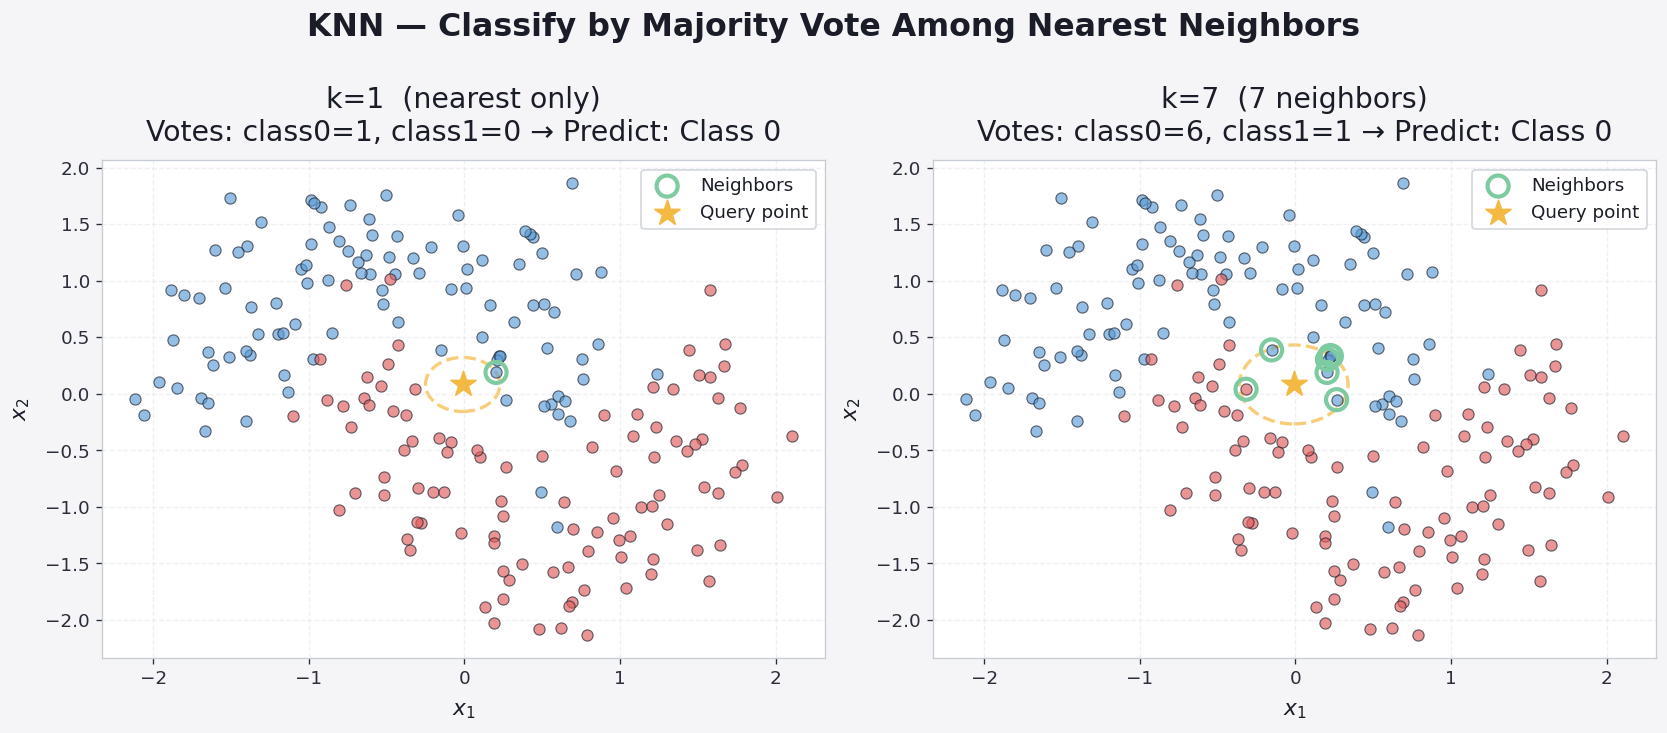

In [3]:
# Illustrate one prediction with neighbourhood circles
np.random.seed(7)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, k_show, title in zip(axes, [1, 7], ['k=1  (nearest only)', 'k=7  (7 neighbors)']):
    query = np.array([[0.5, 0.3]])
    query_s = sc2.transform(query)
    dists = np.sqrt(np.sum((X2s - query_s)**2, axis=1))
    nbr_idx = np.argsort(dists)[:k_show]
    radius  = dists[nbr_idx[-1]]

    for cls, col in [(0, C0), (1, C1)]:
        mask = y2 == cls
        ax.scatter(X2s[mask,0], X2s[mask,1], c=col, s=45,
                   edgecolors='#1a1d27', lw=0.7, alpha=0.65, zorder=3)
    # Neighbors
    ax.scatter(X2s[nbr_idx,0], X2s[nbr_idx,1],
               s=160, facecolors='none', edgecolors=CM,
               linewidths=2.5, zorder=6, label='Neighbors')
    # Query point
    ax.scatter(query_s[0,0], query_s[0,1],
               s=250, c=CB, marker='*', zorder=7, label='Query point')
    # Radius circle
    circle = plt.Circle(query_s[0], radius, fill=False, color=CB,
                        lw=2, ls='--', alpha=0.7)
    ax.add_patch(circle)

    vote0 = np.sum(y2[nbr_idx] == 0)
    vote1 = np.sum(y2[nbr_idx] == 1)
    pred_class = 0 if vote0 > vote1 else 1
    ax.set_title(f'{title}\nVotes: class0={vote0}, class1={vote1} → Predict: Class {pred_class}', pad=12)
    ax.set_xlabel('$x_1$', labelpad=8); ax.set_ylabel('$x_2$', labelpad=8)
    ax.legend(loc='upper right'); ax.grid(True)

fig.suptitle('KNN — Classify by Majority Vote Among Nearest Neighbors',
             fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Effect of $k$ — From Memorisation to Smooth Boundaries

- $k=1$: each training point creates its own Voronoi cell → perfect train accuracy, high variance
- Large $k$: smoothed boundary, lower variance, possibly higher bias

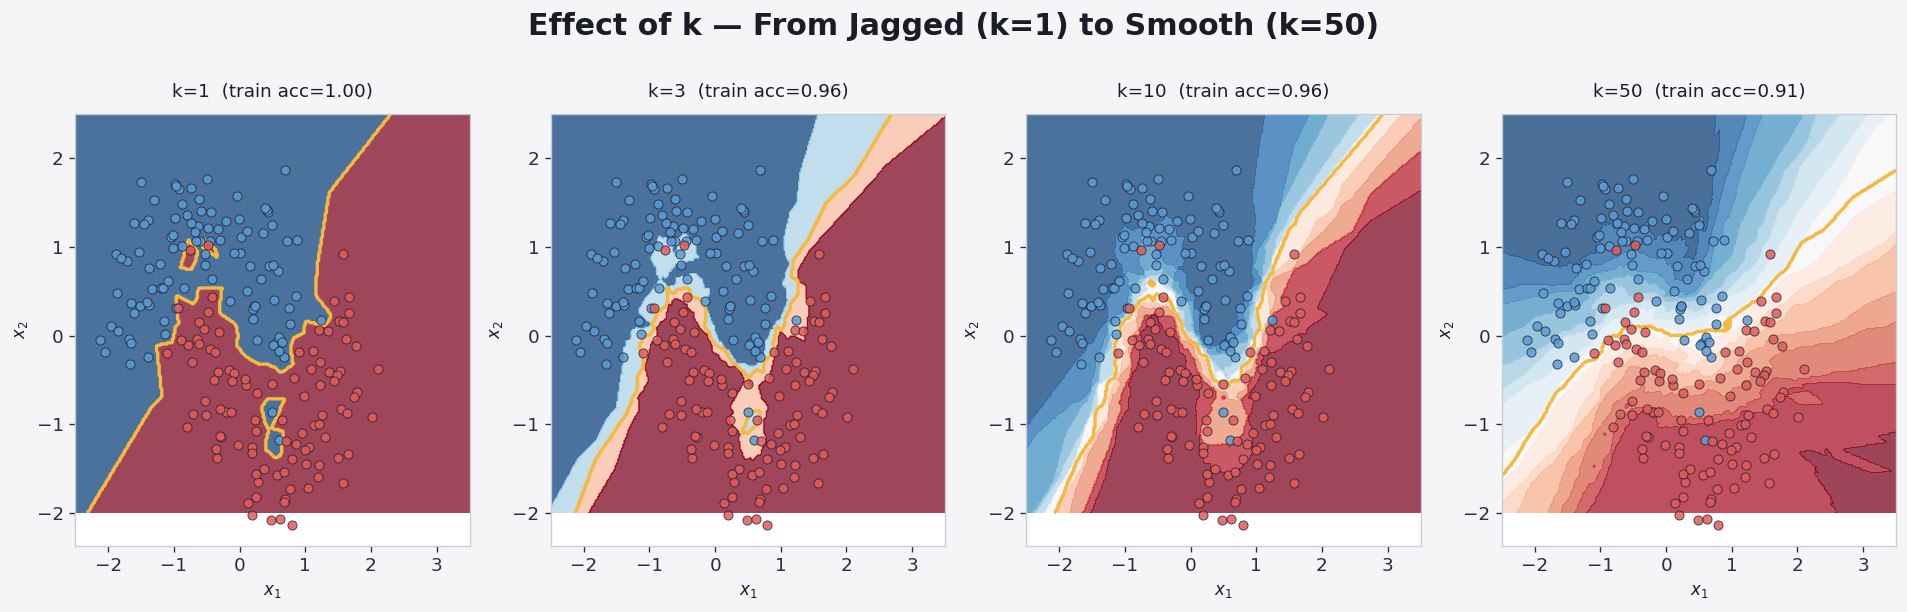

In [4]:
k_values = [1, 3, 10, 50]
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, k_v in zip(axes, k_values):
    knn = KNeighborsClassifier(n_neighbors=k_v)
    knn.fit(X2s, y2)
    ZZ = knn.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, ZZ, levels=15, cmap='RdBu_r', alpha=0.75)
    ax.contour(xx, yy, ZZ, levels=[0.5], colors=CB, linewidths=2)
    ax.scatter(X2s[y2==0,0], X2s[y2==0,1], c=C0, s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.85, zorder=4)
    ax.scatter(X2s[y2==1,0], X2s[y2==1,1], c=C1, s=30, edgecolors='#1a1d27', lw=0.5, alpha=0.85, zorder=4)
    tr_acc = accuracy_score(y2, knn.predict(X2s))
    ax.set_title(f'k={k_v}  (train acc={tr_acc:.2f})', fontsize=11, pad=10)
    ax.set_xlabel('$x_1$', fontsize=10); ax.set_ylabel('$x_2$', fontsize=10)
    ax.grid(False)

fig.suptitle('Effect of k — From Jagged (k=1) to Smooth (k=50)',
             fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Choosing $k$ by Cross-Validation

The optimal $k$ balances the bias-variance tradeoff.
We use cross-validation to find the $k$ with the lowest held-out error.

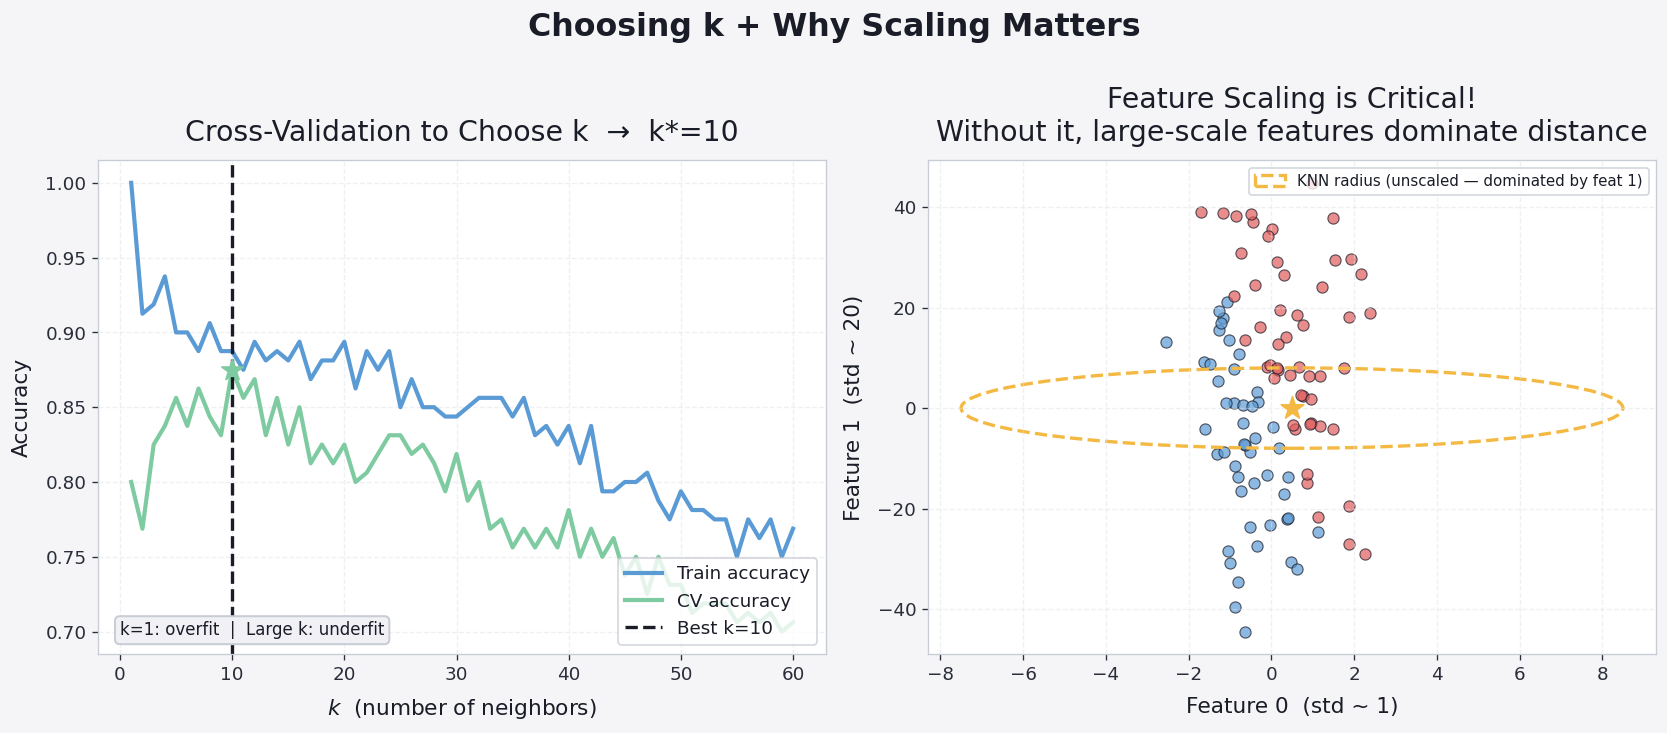

In [5]:
k_range     = range(1, 61)
train_acc_k = []
cv_acc_k    = []

for k_v in k_range:
    knn_k = KNeighborsClassifier(n_neighbors=k_v)
    knn_k.fit(X_tr_s, y_tr)
    train_acc_k.append(accuracy_score(y_tr, knn_k.predict(X_tr_s)))
    cv_score = cross_val_score(KNeighborsClassifier(n_neighbors=k_v),
                               X_tr_s, y_tr, cv=5, scoring='accuracy')
    cv_acc_k.append(cv_score.mean())

best_k = list(k_range)[np.argmax(cv_acc_k)]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.plot(list(k_range), train_acc_k, color=C0, lw=2.5, label='Train accuracy')
ax.plot(list(k_range), cv_acc_k,    color=CM, lw=2.5, label='CV accuracy')
ax.axvline(best_k, color='#1a1d27', ls='--', lw=2, label=f'Best k={best_k}')
ax.scatter([best_k], [cv_acc_k[best_k-1]], s=180, c=CM, marker='*', zorder=7)
ax.set_xlabel('$k$  (number of neighbors)', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title(f'Cross-Validation to Choose k  →  k*={best_k}', pad=12)
ax.legend(loc='lower right'); ax.grid(True)
ax.text(0.03, 0.03, 'k=1: overfit  |  Large k: underfit',
        transform=ax.transAxes, fontsize=10, va='bottom',
        bbox=dict(boxstyle='round', fc='#f0f0f5', ec='#c8ccd4', lw=1.2))

# Right: why scaling matters
np.random.seed(0)
X_unscaled = np.random.randn(100, 2)
X_unscaled[:, 1] *= 20   # feature 1 has much larger scale
y_us = (X_unscaled[:,0] + X_unscaled[:,1]/20 > 0).astype(int)

X_us_raw = X_unscaled.copy()
X_us_sc  = StandardScaler().fit_transform(X_unscaled)

ax = axes[1]
for col, label, marker, X_plot in [
    (C0, 'Feature-1 dom. (class 0)', 'o', X_us_raw[y_us==0]),
    (C1, 'Feature-1 dom. (class 1)', 'o', X_us_raw[y_us==1]),
]:
    ax.scatter(X_plot[:,0], X_plot[:,1], c=col, s=45, edgecolors='#1a1d27', lw=0.7, alpha=0.7)
# Show a query circle in raw vs scaled space
query_raw = np.array([[0.5, 0.0]])
circle_raw = plt.Circle(query_raw[0], 8, fill=False, color=CB, lw=2, ls='--',
                         label='KNN radius (unscaled — dominated by feat 1)')
ax.add_patch(circle_raw)
ax.scatter(*query_raw[0], s=200, c=CB, marker='*', zorder=7)
ax.set_xlabel('Feature 0  (std ~ 1)', labelpad=8); ax.set_ylabel('Feature 1  (std ~ 20)', labelpad=8)
ax.set_title('Feature Scaling is Critical!\nWithout it, large-scale features dominate distance', pad=12)
ax.legend(loc='upper right', fontsize=9); ax.grid(True)

fig.suptitle('Choosing k + Why Scaling Matters', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Visual Sweep — How $k$ Reshapes the Boundary

The grid below shows the **same data** with KNN fit at six values of $k$. Hollow rings mark the $k$ nearest neighbors of a fixed query point (the gold star) so you can literally see which votes determine its class.

Reading across the panels:

- **$k = 1$** — each training point owns a Voronoi cell. Boundary is jagged; perfect train accuracy; high variance.
- **Small–medium $k$ (3–7)** — boundary smooths; bias and variance balance.
- **Large $k$ (30–50)** — vast neighborhood; predictions tilt toward the **majority class** of the whole dataset → underfitting.

The follow-up plot tracks train, test, and 5-fold CV accuracy across $k$, with a gold star at the CV-optimal $k^{\star}$.


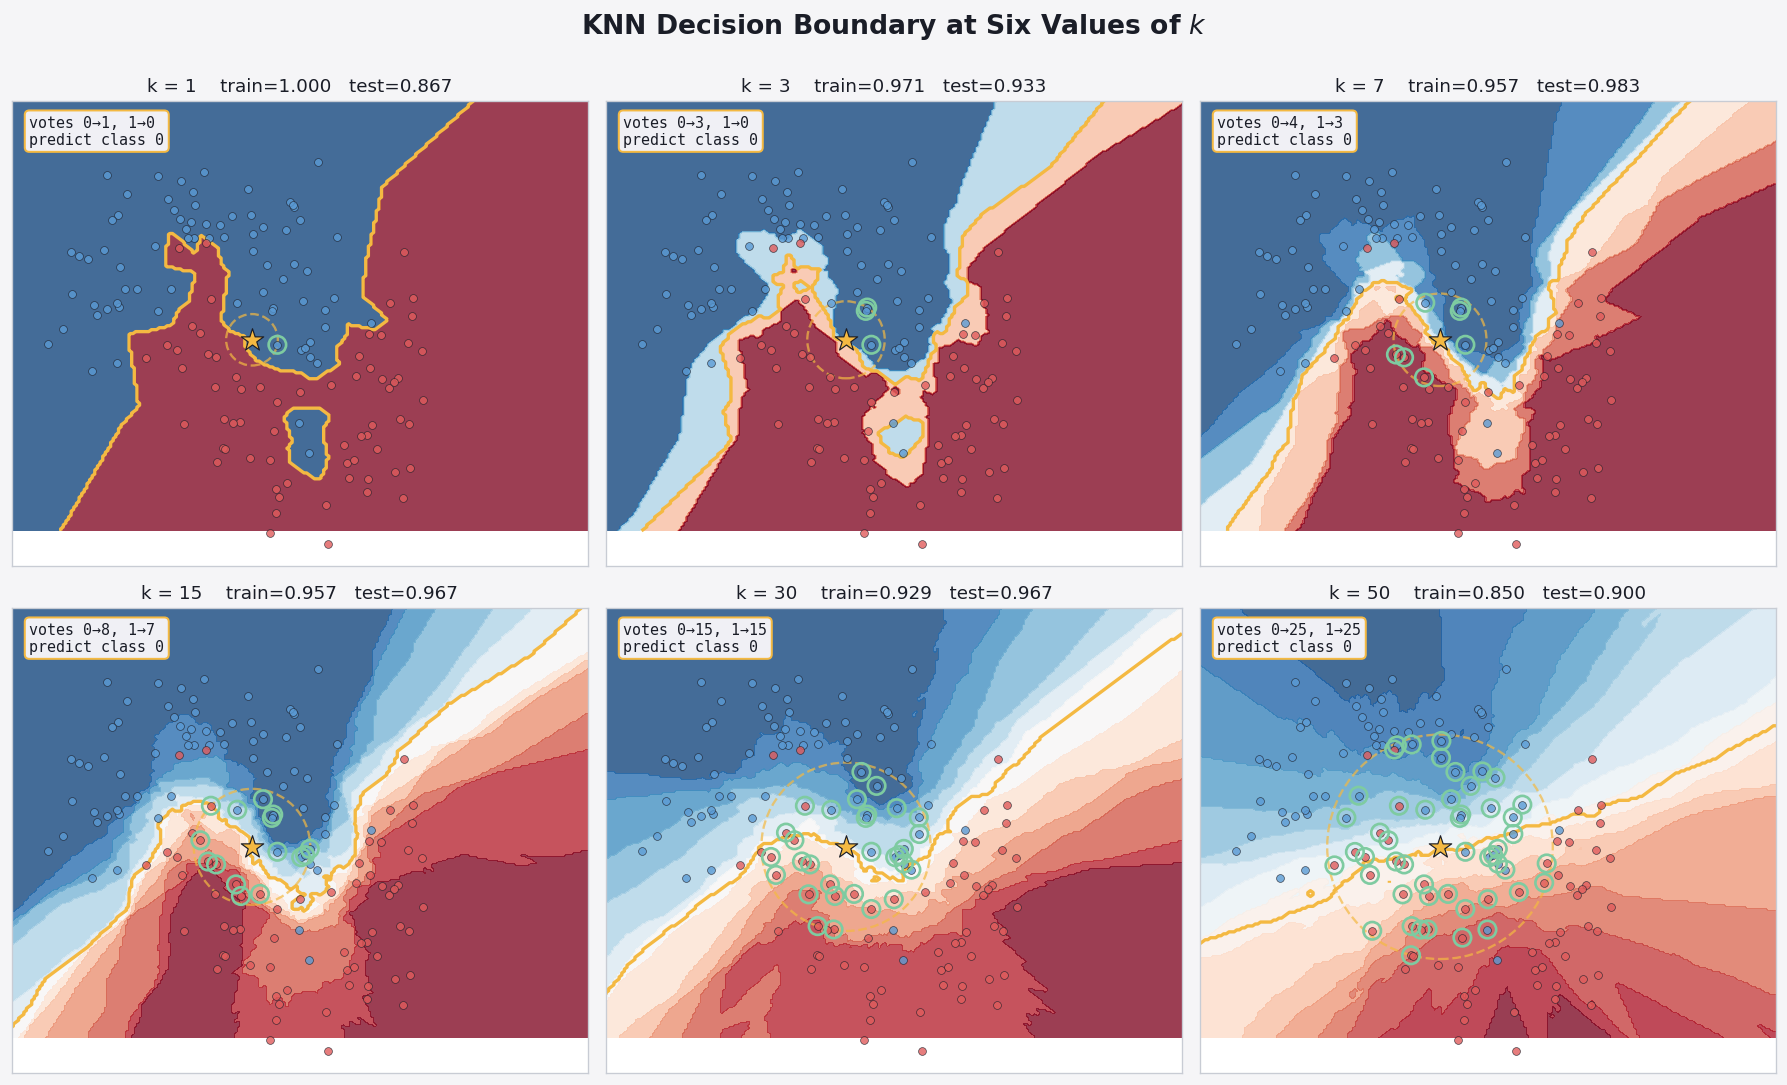

In [6]:
# 70/30 split on the 2-D moons for a held-out train/test view
_perm = np.random.default_rng(11).permutation(len(X2s))
_cut  = int(0.70 * len(X2s))
_Xtr_k, _ytr_k = X2s[_perm[:_cut]], y2[_perm[:_cut]]
_Xte_k, _yte_k = X2s[_perm[_cut:]], y2[_perm[_cut:]]

_xx_k, _yy_k = np.meshgrid(np.linspace(-2.5, 3.5, 220),
                           np.linspace(-2.0, 2.5, 220))

# Fixed query point so the neighbor rings stay visually anchored
_query_k = np.array([0.0, 0.0])

# Six representative k values spanning under-fit ← → over-fit
_k_panel = [1, 3, 7, 15, 30, 50]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, k in zip(axes.ravel(), _k_panel):
    knn = KNeighborsClassifier(n_neighbors=k).fit(_Xtr_k, _ytr_k)
    ZZ  = knn.predict_proba(np.c_[_xx_k.ravel(), _yy_k.ravel()])[:, 1].reshape(_xx_k.shape)
    tr_acc = accuracy_score(_ytr_k, knn.predict(_Xtr_k))
    te_acc = accuracy_score(_yte_k, knn.predict(_Xte_k))

    _d = np.sqrt(np.sum((_Xtr_k - _query_k) ** 2, axis=1))
    nbr_idx = np.argsort(_d)[:k]
    radius  = _d[nbr_idx[-1]]
    vote0 = int(np.sum(_ytr_k[nbr_idx] == 0))
    vote1 = int(np.sum(_ytr_k[nbr_idx] == 1))
    pred  = 1 if vote1 > vote0 else 0

    ax.contourf(_xx_k, _yy_k, ZZ, levels=15, cmap='RdBu_r', alpha=0.78)
    ax.contour(_xx_k, _yy_k, ZZ, levels=[0.5], colors=CB, linewidths=2.0)
    ax.scatter(_Xtr_k[_ytr_k == 0, 0], _Xtr_k[_ytr_k == 0, 1],
               c=C0, s=22, edgecolors='#1a1d27', lw=0.4, alpha=0.80, zorder=4)
    ax.scatter(_Xtr_k[_ytr_k == 1, 0], _Xtr_k[_ytr_k == 1, 1],
               c=C1, s=22, edgecolors='#1a1d27', lw=0.4, alpha=0.80, zorder=4)
    ax.scatter(_Xtr_k[nbr_idx, 0], _Xtr_k[nbr_idx, 1],
               s=110, facecolors='none', edgecolors=CM, lw=1.6, zorder=6)
    circ = plt.Circle(_query_k, radius, fill=False, color=CB, lw=1.4, ls='--', alpha=0.7)
    ax.add_patch(circ)
    ax.scatter(*_query_k, s=200, c=CB, marker='*', zorder=7,
               edgecolors='#1a1d27', linewidths=0.7)
    ax.set_title(f'k = {k}    train={tr_acc:.3f}   test={te_acc:.3f}',
                 fontsize=11, pad=6)
    ax.text(0.03, 0.97,
            f'votes 0→{vote0}, 1→{vote1}\npredict class {pred}',
            transform=ax.transAxes, fontsize=9, va='top', family='monospace',
            bbox=dict(boxstyle='round', fc='#f0f0f5', ec=CB, lw=1.2))
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle('KNN Decision Boundary at Six Values of $k$',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout(); plt.show()


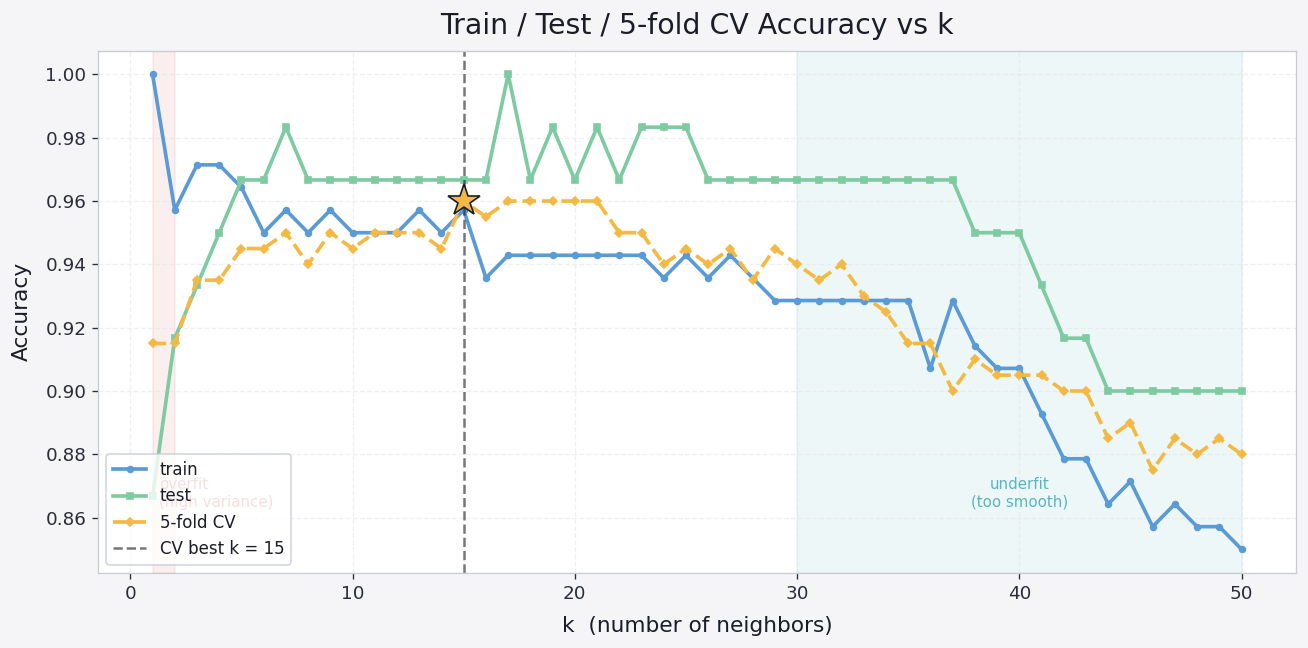

In [7]:
# Train / test / 5-fold CV accuracy as k sweeps
_k_grid = list(range(1, 51))
_tr_k_curve, _te_k_curve, _cv_k_curve = [], [], []
for _k in _k_grid:
    _kn = KNeighborsClassifier(n_neighbors=_k).fit(_Xtr_k, _ytr_k)
    _tr_k_curve.append(accuracy_score(_ytr_k, _kn.predict(_Xtr_k)))
    _te_k_curve.append(accuracy_score(_yte_k, _kn.predict(_Xte_k)))
    _cv_k_curve.append(cross_val_score(KNeighborsClassifier(n_neighbors=_k),
                                       X2s, y2, cv=5, scoring='accuracy').mean())
_best_k_local = _k_grid[int(np.argmax(_cv_k_curve))]

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(_k_grid, _tr_k_curve, color=C0, lw=2.2, marker='o', ms=3.5, label='train')
ax.plot(_k_grid, _te_k_curve, color=CM, lw=2.2, marker='s', ms=3.5, label='test')
ax.plot(_k_grid, _cv_k_curve, color=CB, lw=2.2, ls='--', marker='D', ms=3.5, label='5-fold CV')
ax.axvline(_best_k_local, color='#1a1d27', ls='--', lw=1.5, alpha=0.6,
           label=f'CV best k = {_best_k_local}')
ax.plot([_best_k_local], [max(_cv_k_curve)], marker='*', ms=20,
        color=CB, mec='#1a1d27', mew=1.0, zorder=10)

ax.axvspan(1, 2,  alpha=0.10, color=C1)
ax.axvspan(30, 50, alpha=0.10, color=CH)
ax.text(1.3, ax.get_ylim()[0] + 0.02, 'overfit\n(high variance)',
        color=C1, fontsize=9, va='bottom')
ax.text(40, ax.get_ylim()[0] + 0.02, 'underfit\n(too smooth)',
        color=CH, fontsize=9, va='bottom', ha='center')

ax.set_xlabel('k  (number of neighbors)', labelpad=8)
ax.set_ylabel('Accuracy', labelpad=8)
ax.set_title('Train / Test / 5-fold CV Accuracy vs k', pad=10)
ax.legend(loc='lower left', fontsize=10); ax.grid(True)
plt.tight_layout(); plt.show()


---
## Failure Mode — The Curse of Dimensionality

KNN relies on a meaningful notion of "nearby". In high dimensions, **all points are roughly equidistant** — distances concentrate around a single value, so the "nearest" neighbor becomes barely closer than the "farthest", and the majority vote loses its edge.

The diagnostic below shows two symptoms as dimensionality $d$ grows:
1. **Left:** the ratio $d_{\min} / d_{\max}$ of nearest-to-farthest neighbor distance → it shrinks toward 1 (everything is at the same distance).
2. **Right:** the **gap** between KNN test accuracy and a baseline (logistic regression) collapses, because neighborhoods stop being informative.


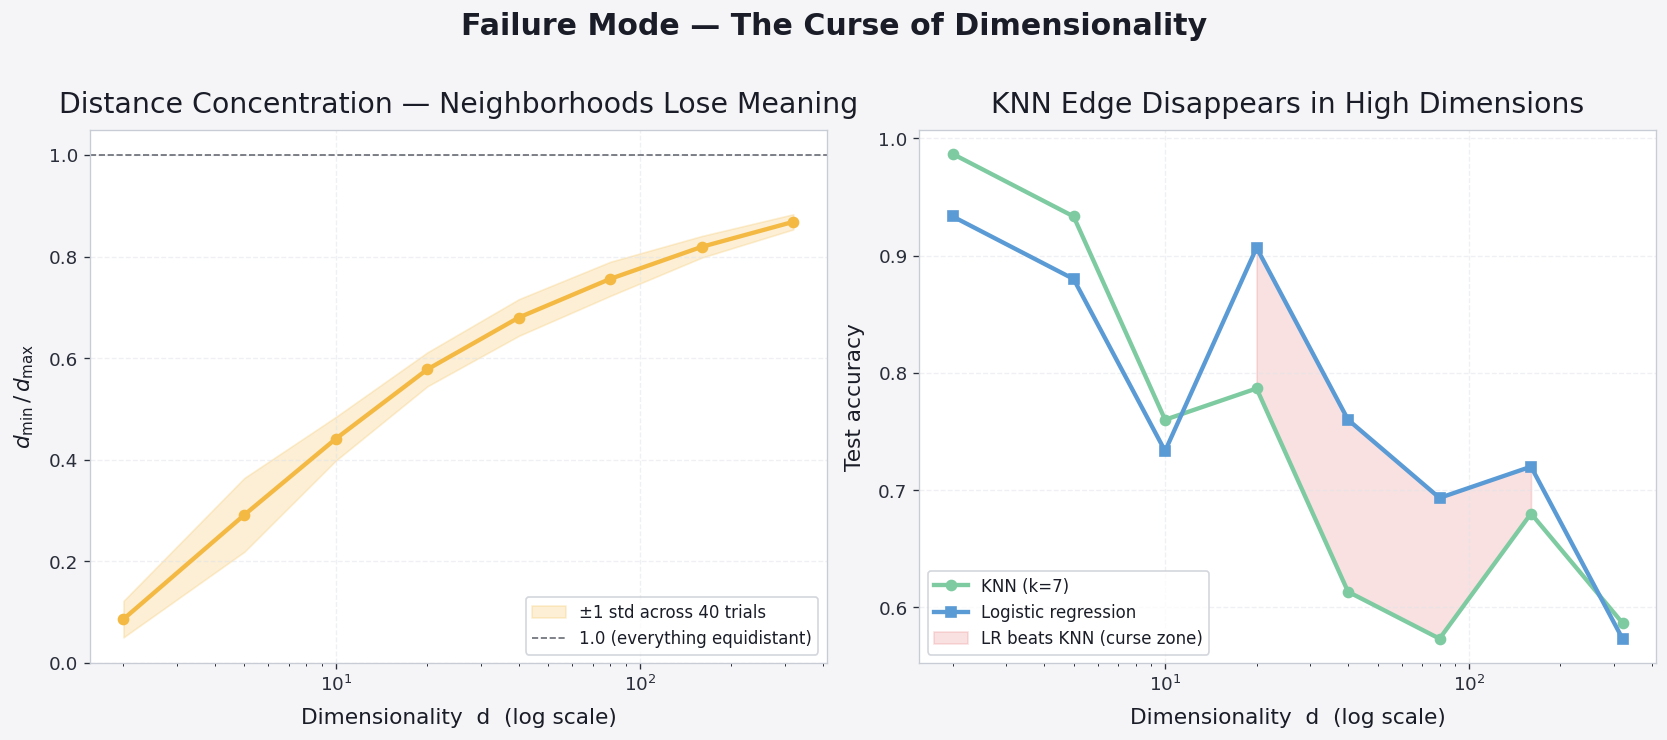

In [8]:
from sklearn.linear_model import LogisticRegression as _LR_curse

_dims = [2, 5, 10, 20, 40, 80, 160, 320]
_rng_curse = np.random.default_rng(13)
_ratio_mean, _ratio_std = [], []
_knn_acc, _lr_acc = [], []

for _d in _dims:
    # 1) distance concentration on iid uniform samples
    _U = _rng_curse.uniform(0.0, 1.0, size=(400, _d))
    _q = _rng_curse.uniform(0.0, 1.0, size=(_d,))
    _dd = np.sqrt(((_U - _q) ** 2).sum(axis=1))
    _ratios = []
    for _ in range(40):
        _idx = _rng_curse.choice(len(_dd), size=50, replace=False)
        _sub = _dd[_idx]
        _ratios.append(_sub.min() / _sub.max())
    _ratio_mean.append(float(np.mean(_ratios)))
    _ratio_std.append(float(np.std(_ratios)))

    # 2) classification benchmark
    _Xd, _yd = make_classification(
        n_samples=250, n_features=_d,
        n_informative=min(5, _d), n_redundant=0,
        random_state=int(_d),
    )
    _Xd = StandardScaler().fit_transform(_Xd)
    _Xdt, _Xde, _ydt, _yde = train_test_split(_Xd, _yd, test_size=0.30, random_state=0)
    _knn_acc.append(accuracy_score(_yde,
                    KNeighborsClassifier(n_neighbors=7).fit(_Xdt, _ydt).predict(_Xde)))
    _lr_acc.append(accuracy_score(_yde,
                    _LR_curse(max_iter=2000).fit(_Xdt, _ydt).predict(_Xde)))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: distance concentration ────────────────────────────────
ax = axes[0]
_rm = np.array(_ratio_mean); _rs = np.array(_ratio_std)
ax.plot(_dims, _rm, color=CB, lw=2.6, marker='o', ms=6)
ax.fill_between(_dims, _rm - _rs, _rm + _rs, color=CB, alpha=0.22,
                label='±1 std across 40 trials')
ax.axhline(1.0, color='#2a2e3a', ls='--', lw=1.0, alpha=0.7,
           label='1.0 (everything equidistant)')
ax.set_xscale('log')
ax.set_xlabel('Dimensionality  d  (log scale)', labelpad=8)
ax.set_ylabel(r'$d_{\min}\, /\, d_{\max}$', labelpad=8)
ax.set_title('Distance Concentration — Neighborhoods Lose Meaning', pad=10)
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right', fontsize=10); ax.grid(True)

# ── Right: KNN vs LogReg as d grows ─────────────────────────────
ax = axes[1]
ax.semilogx(_dims, _knn_acc, color=CM, lw=2.6, marker='o', ms=6, label='KNN (k=7)')
ax.semilogx(_dims, _lr_acc,  color=C0, lw=2.6, marker='s', ms=6, label='Logistic regression')
ax.fill_between(_dims, _knn_acc, _lr_acc,
                where=np.array(_lr_acc) > np.array(_knn_acc),
                color=C1, alpha=0.18, label='LR beats KNN (curse zone)')
ax.set_xlabel('Dimensionality  d  (log scale)', labelpad=8)
ax.set_ylabel('Test accuracy', labelpad=8)
ax.set_title('KNN Edge Disappears in High Dimensions', pad=10)
ax.legend(loc='lower left', fontsize=10); ax.grid(True)

fig.suptitle('Failure Mode — The Curse of Dimensionality',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()


---
## Metrics — Confusion Matrix & ROC

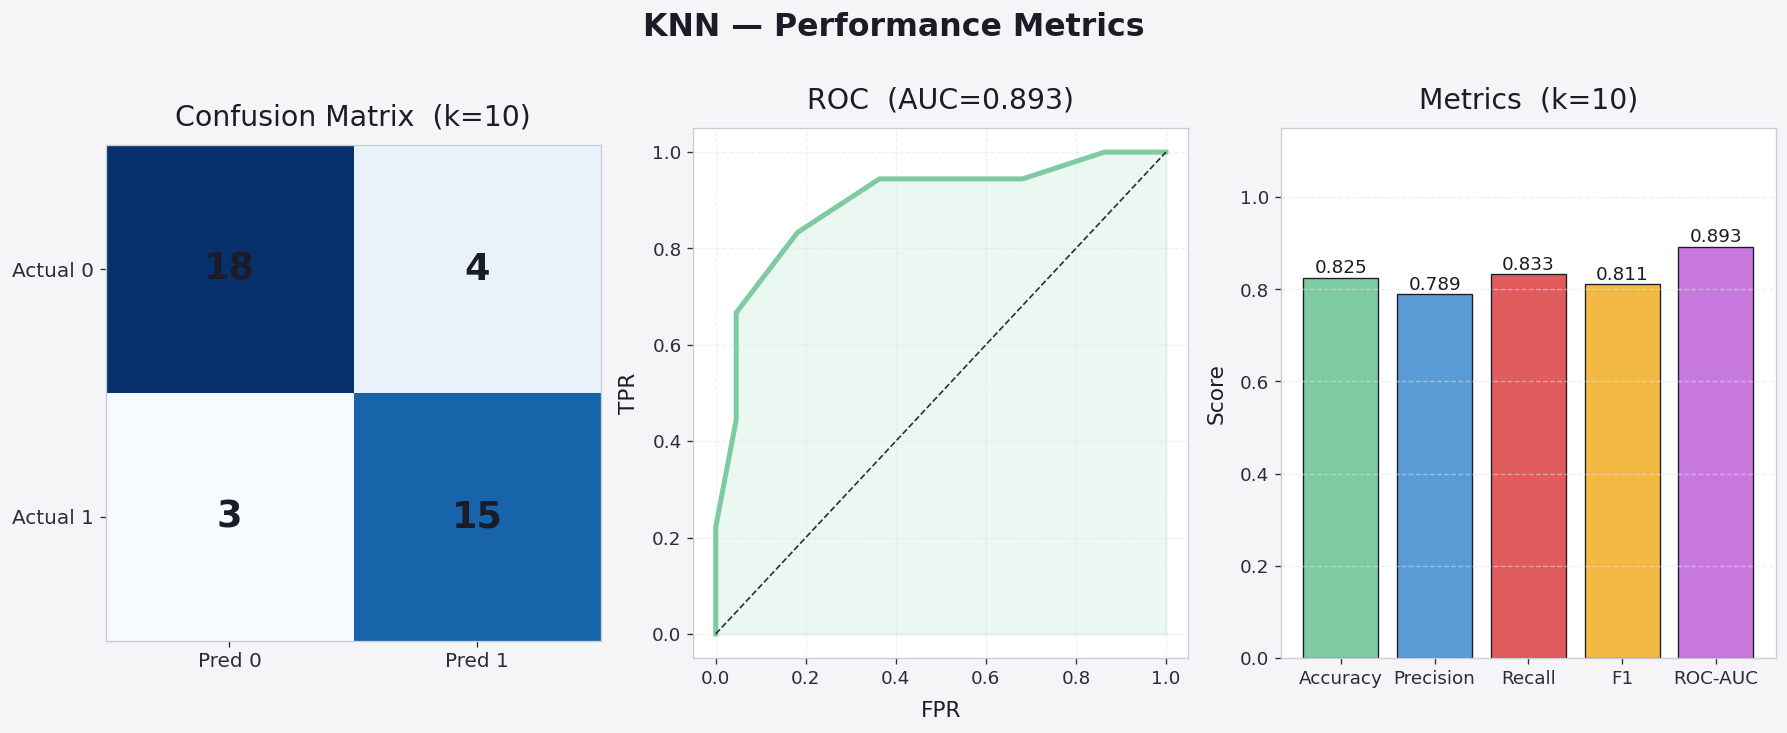

In [9]:
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_tr_s, y_tr)
preds   = knn_final.predict(X_te_s)
probs   = knn_final.predict_proba(X_te_s)[:,1]
cm      = confusion_matrix(y_te, preds)
fpr, tpr, _ = roc_curve(y_te, probs)
roc_auc = auc(fpr, tpr)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

ax = axes[0]
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=22, fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred 0','Pred 1'], fontsize=12)
ax.set_yticklabels(['Actual 0','Actual 1'], fontsize=12)
ax.set_title(f'Confusion Matrix  (k={best_k})', pad=12)

ax = axes[1]
ax.plot(fpr, tpr, color=CM, lw=3)
ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_xlabel('FPR', labelpad=8); ax.set_ylabel('TPR', labelpad=8)
ax.set_title(f'ROC  (AUC={roc_auc:.3f})', pad=12); ax.grid(True)

ax = axes[2]
metrics_vals = {
    'Accuracy':  accuracy_score(y_te, preds),
    'Precision': precision_score(y_te, preds),
    'Recall':    recall_score(y_te, preds),
    'F1':        f1_score(y_te, preds),
    'ROC-AUC':   roc_auc,
}
bars = ax.bar(list(metrics_vals.keys()), list(metrics_vals.values()),
              color=[CM, C0, C1, CB, CP], edgecolor='#1a1d27', lw=0.8)
for bar, val in zip(bars, metrics_vals.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.3f}', ha='center', fontsize=11)
ax.set_ylim(0, 1.15); ax.set_ylabel('Score', labelpad=8)
ax.set_title(f'Metrics  (k={best_k})', pad=12); ax.grid(True, axis='y')

fig.suptitle('KNN — Performance Metrics', fontsize=19, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

---
## Everything on One Canvas

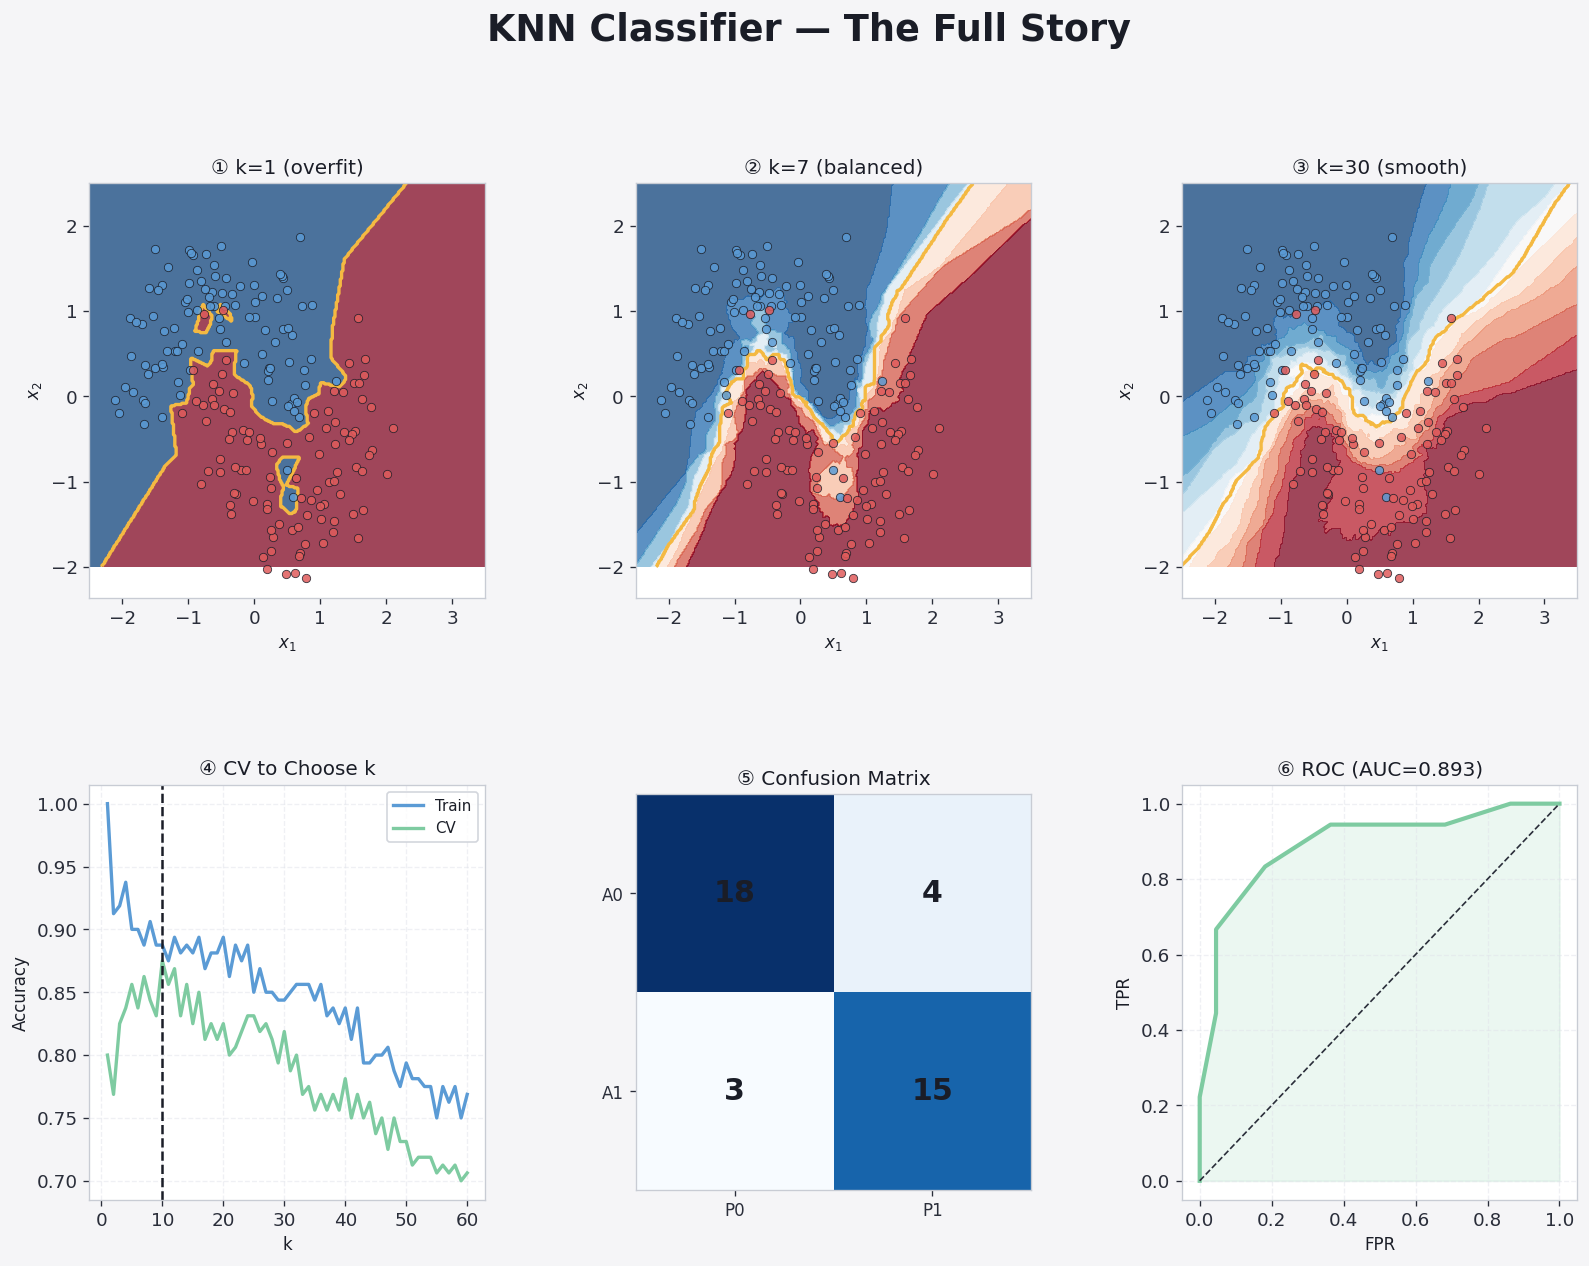

In [10]:
fig = plt.figure(figsize=(16, 11), facecolor='#f5f5f7')
gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

for subplot_idx, k_v in enumerate([1, 7, 30]):
    ax = fig.add_subplot(gs[0, subplot_idx])
    knn_v = KNeighborsClassifier(n_neighbors=k_v)
    knn_v.fit(X2s, y2)
    ZZv = knn_v.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:,1].reshape(xx.shape)
    ax.contourf(xx, yy, ZZv, levels=15, cmap='RdBu_r', alpha=0.75)
    ax.contour(xx, yy, ZZv, levels=[0.5], colors=CB, linewidths=2)
    ax.scatter(X2s[y2==0,0], X2s[y2==0,1], c=C0, s=25, edgecolors='#1a1d27', lw=0.5, alpha=0.85, zorder=4)
    ax.scatter(X2s[y2==1,0], X2s[y2==1,1], c=C1, s=25, edgecolors='#1a1d27', lw=0.5, alpha=0.85, zorder=4)
    lbl = ['① k=1 (overfit)', '② k=7 (balanced)', '③ k=30 (smooth)'][subplot_idx]
    ax.set_title(lbl, fontsize=12)
    ax.set_xlabel('$x_1$', fontsize=10); ax.set_ylabel('$x_2$', fontsize=10)

ax = fig.add_subplot(gs[1, 0])
ax.plot(list(k_range), train_acc_k, color=C0, lw=2, label='Train')
ax.plot(list(k_range), cv_acc_k, color=CM, lw=2, label='CV')
ax.axvline(best_k, color='#1a1d27', ls='--', lw=1.5)
ax.set_title('④ CV to Choose k', fontsize=12)
ax.set_xlabel('k', fontsize=10); ax.set_ylabel('Accuracy', fontsize=10)
ax.legend(fontsize=9); ax.grid(True)

ax = fig.add_subplot(gs[1, 1])
ax.imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax.text(j,i,str(cm[i,j]),ha='center',va='center',fontsize=18,fontweight='bold',
                color='#1a1d27' if cm[i,j]>cm.max()/2 else '#1a1d27')
ax.set_xticks([0,1]);ax.set_yticks([0,1])
ax.set_xticklabels(['P0','P1'],fontsize=10);ax.set_yticklabels(['A0','A1'],fontsize=10)
ax.set_title('⑤ Confusion Matrix', fontsize=12)

ax = fig.add_subplot(gs[1, 2])
ax.plot(fpr, tpr, color=CM, lw=2.5); ax.fill_between(fpr, tpr, alpha=0.15, color=CM)
ax.plot([0,1],[0,1], color='#2a2e3a', ls='--', lw=1)
ax.set_title(f'⑥ ROC (AUC={roc_auc:.3f})', fontsize=12)
ax.set_xlabel('FPR', fontsize=10); ax.set_ylabel('TPR', fontsize=10); ax.grid(True)

fig.suptitle('KNN Classifier — The Full Story', fontsize=22, fontweight='bold', color='#1a1d27', y=1.01)
plt.show()

---
## ⚖️ When to use KNN — and when not to

| Situation | KNN | Logistic | SVM | Random Forest |
|---|---|---|---|---|
| Very small $d$, irregular boundary | ✅ | ❌ | partial | ✅ |
| High-D ($d > 50$) | ❌ curse | ✅ | ✅ | ✅ |
| Need fast predict | ❌ $O(n)$ per query | ✅ | ✅ | ✅ |
| Need to reason / explain | ❌ "look at neighbours" | ✅ | ❌ | partial |

> KNN is a great **sanity check** and works well in low-D when you don't need a model to deploy.


---
## 🎯 Try this

1. **Scale matters.** Re-run with one feature multiplied by 100. The neighbours should change radically — confirms that you must standardise before using KNN.
2. **Weight by distance.** Use `weights='distance'` instead of uniform votes. Decision boundary should tighten near the data and loosen far from it.
3. **Approximate NN.** Use `BallTree` or `KDTree` and time the query. Then try `pynndescent` / `faiss` — for $n > 10^4$ the speedup is enormous.


---
## Summary

| Concept | Description | Key Insight |
|---|---|---|
| Prediction | Majority vote among $k$ nearest training points | No explicit model is trained |
| $k=1$ | 1-NN: Voronoi diagram — perfect train accuracy | Maximum variance; memorises training set |
| Large $k$ | Smooth boundary, majority class dominates | High bias; ignores local structure |
| Optimal $k$ | Found by cross-validation | Typically 5–30 for most datasets |
| Distance metric | Euclidean ($L_2$) by default | Manhattan ($L_1$) can be more robust |
| **Feature scaling** | **Critical** — always standardise | Unscaled features dominate distance |
| Curse of dimensionality | All points become equidistant in high dimensions | KNN degrades rapidly with many features |
| No training phase | Store all training data; predict at query time | Slow at inference; fast at training |

**Key insight:** KNN is a **lazy learner** — it stores the training set and defers all computation to prediction time. Its simplicity is a strength (no assumptions, naturally handles multi-class), but it requires feature scaling and struggles in high dimensions where the concept of "nearest" becomes meaningless.